# Verify 2018 Data Merge

This notebook creates line plots showing yearly counts for each Personal Focus Crime from 2003-2025 to validate the merge between historical and recent datasets.

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load merged data
print("Loading merged crime data...")
df = pd.read_csv('../files/merged_crime_data_2003_2025.csv')
print(f"✓ Loaded {len(df):,} records")
print(f"\nColumns: {df.columns.tolist()}")

Loading merged crime data...
✓ Loaded 1,317,318 records

Columns: ['Incident_Number', 'Incident_Date', 'Incident_Time', 'Original_Category', 'Unified_Category', 'Description', 'Police_District', 'Resolution', 'Latitude', 'Longitude', 'Data_Source', 'Year', 'Month', 'DayOfWeek', 'DayName', 'Hour']


In [10]:
# Check date column and convert to datetime
print("\nDate column info:")
print(df['Incident_Date'].head())
print(f"Data type: {df['Incident_Date'].dtype}")

df['Incident_Date'] = pd.to_datetime(df['Incident_Date'])
df['Year'] = df['Incident_Date'].dt.year

print(f"\nYear range: {df['Year'].min()} to {df['Year'].max()}")
print(f"\nRecords per year:")
print(df['Year'].value_counts().sort_index())


Date column info:
0    2022-04-14
1    2022-05-01
2    2022-05-11
3    2022-04-15
4    2022-05-11
Name: Incident_Date, dtype: object
Data type: object

Year range: 2003 to 2025

Records per year:
Year
2003    56438
2004    56038
2005    57612
2006    57129
2007    52717
2008    52921
2009    49342
2010    46481
2011    47725
2012    55233
2013    60051
2014    62276
2015    67511
2016    63778
2017    70239
2018    69673
2019    67453
2020    52899
2021    59660
2022    65162
2023    62661
2024    46977
2025    37342
Name: count, dtype: int64


In [11]:
# Your 9 Personal Focus Crimes
personal_focus_crimes = [
    'Arson',
    'Assault',
    'Burglary',
    'Disorderly Conduct',
    'Embezzlement',
    'Fraud',
    'Larceny/Theft',
    'Liquor Laws',
    'Missing Person'
]

# Check what column contains the unified crime categories
print("\nLooking for crime category column...")
category_cols = [col for col in df.columns if 'category' in col.lower() or 'unified' in col.lower()]
print(f"Possible category columns: {category_cols}")

# Use the appropriate column (adjust if needed)
if 'Unified_Category' in df.columns:
    category_col = 'Unified_Category'
elif 'Category' in df.columns:
    category_col = 'Category'
else:
    category_col = category_cols[0] if category_cols else None

print(f"\nUsing category column: {category_col}")
print(f"\nUnique categories in data: {df[category_col].nunique()}")
print(f"\nSample categories:")
print(df[category_col].value_counts().head(15))


Looking for crime category column...
Possible category columns: ['Original_Category', 'Unified_Category']

Using category column: Unified_Category

Unique categories in data: 12

Sample categories:
Unified_Category
Larceny/Theft         695660
Assault               163109
Vehicle Theft         144241
Burglary              119319
Robbery                58445
Fraud                  54235
Missing Person         52608
Disorderly Conduct     17555
Arson                   5443
Embezzlement            3512
Suicide                 1599
Liquor Laws             1592
Name: count, dtype: int64


In [12]:
# Filter to Personal Focus Crimes
df_focus = df[df[category_col].isin(personal_focus_crimes)].copy()
print(f"\n✓ Filtered to {len(personal_focus_crimes)} Personal Focus Crimes")
print(f"✓ Total records: {len(df_focus):,}")
print(f"\nRecords per crime type:")
for crime in personal_focus_crimes:
    count = len(df_focus[df_focus[category_col] == crime])
    print(f"  {crime:25s}: {count:,}")


✓ Filtered to 9 Personal Focus Crimes
✓ Total records: 1,113,033

Records per crime type:
  Arson                    : 5,443
  Assault                  : 163,109
  Burglary                 : 119,319
  Disorderly Conduct       : 17,555
  Embezzlement             : 3,512
  Fraud                    : 54,235
  Larceny/Theft            : 695,660
  Liquor Laws              : 1,592
  Missing Person           : 52,608


In [13]:
# Create yearly counts for each crime type
yearly_counts = {}
for crime in personal_focus_crimes:
    crime_data = df_focus[df_focus[category_col] == crime]
    yearly_counts[crime] = crime_data.groupby('Year').size()

print("\n✓ Created yearly count data for all crime types")


✓ Created yearly count data for all crime types


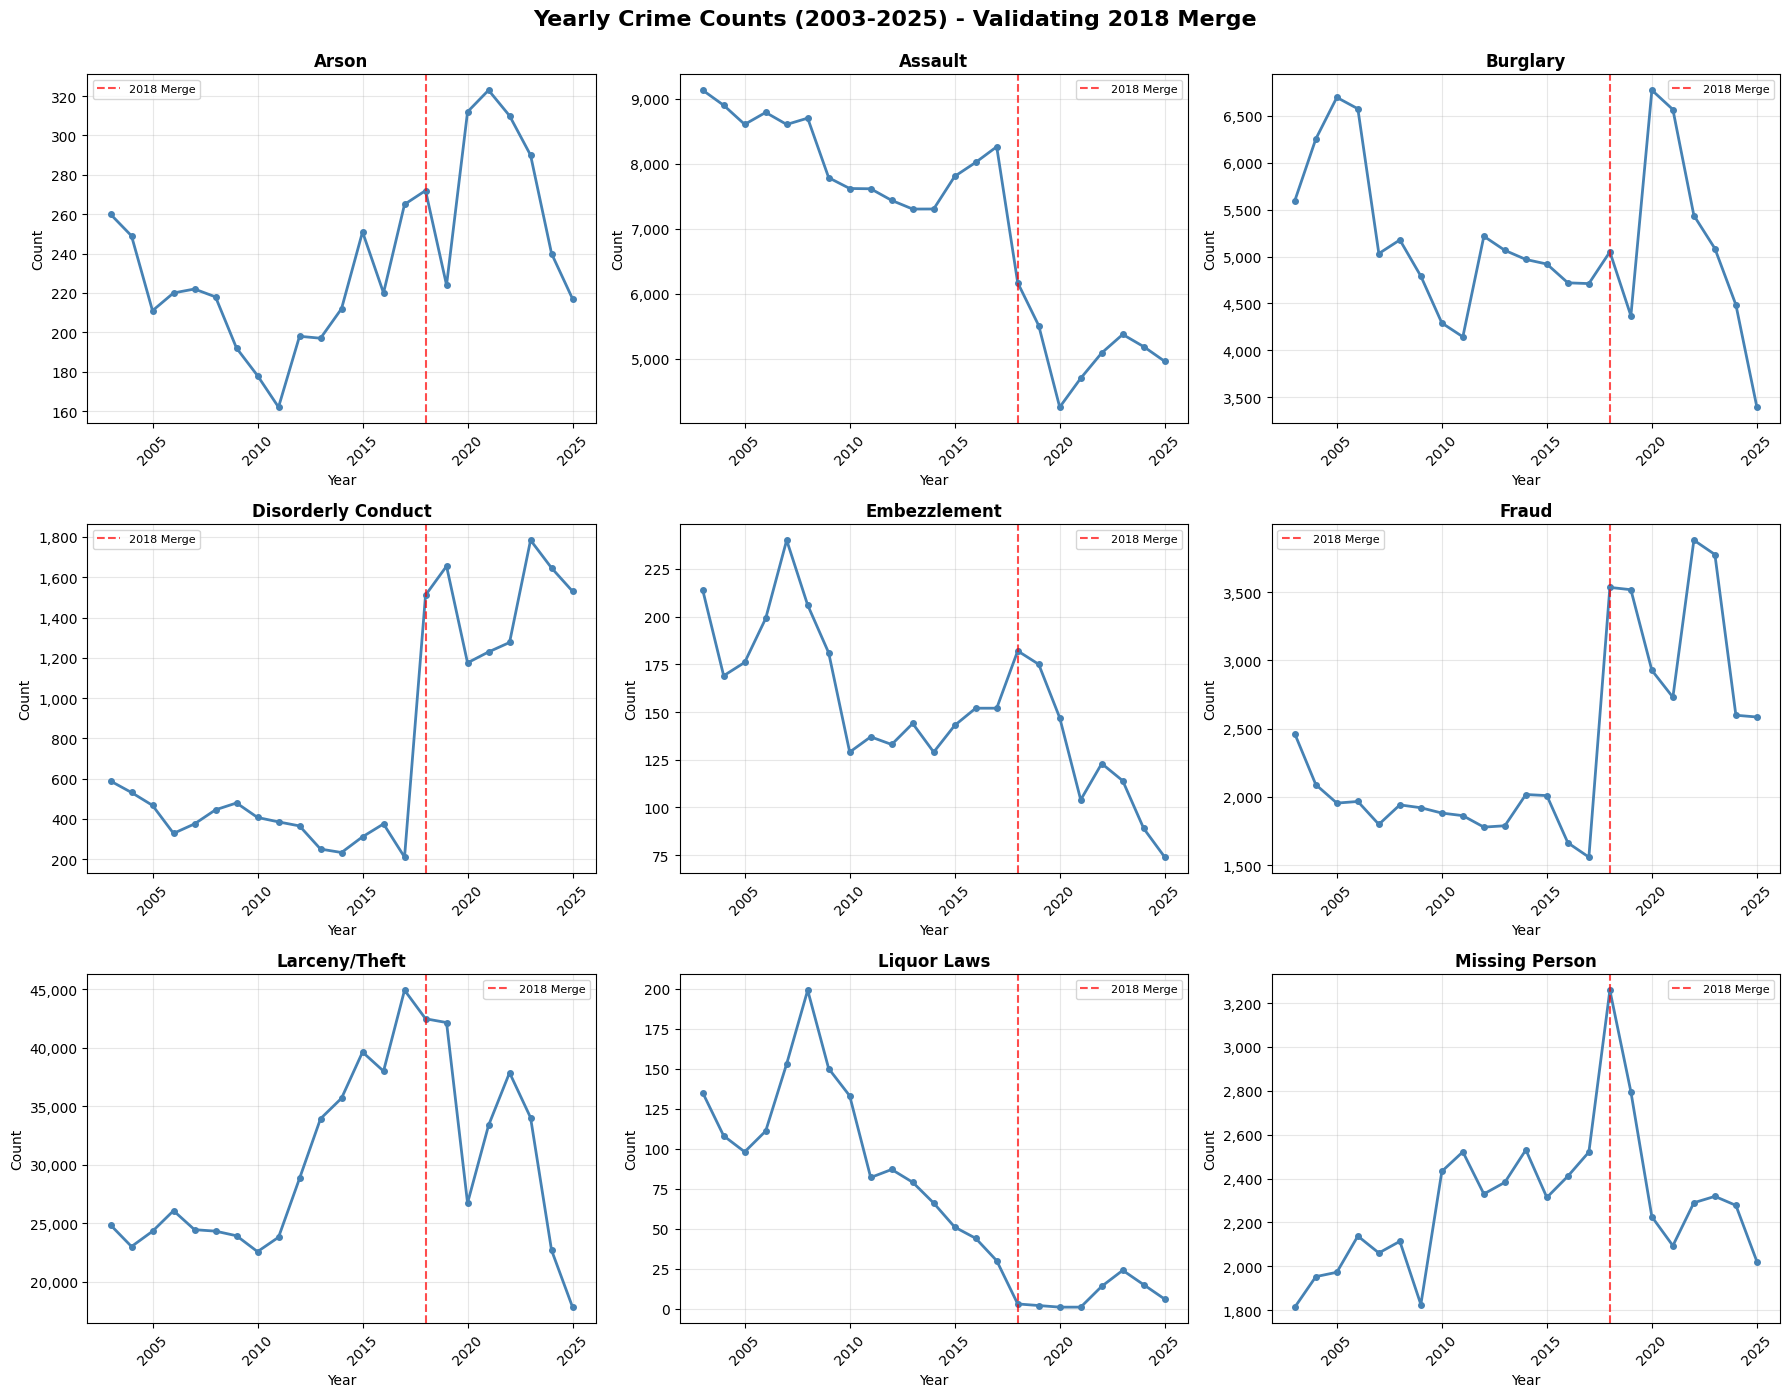


✓ Plot saved as 'crime_yearly_validation_2018.png'


In [14]:
# Create line plots - 3x3 grid
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
fig.suptitle('Yearly Crime Counts (2003-2025) - Validating 2018 Merge', 
             fontsize=16, fontweight='bold', y=0.995)

axes = axes.flatten()

for idx, crime in enumerate(personal_focus_crimes):
    ax = axes[idx]
    
    # Get data
    years = yearly_counts[crime].index
    counts = yearly_counts[crime].values
    
    # Plot line
    ax.plot(years, counts, marker='o', linewidth=2, markersize=4, color='steelblue')
    
    # Highlight 2018 transition
    ax.axvline(x=2018, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='2018 Merge')
    
    # Styling
    ax.set_title(crime, fontsize=12, fontweight='bold')
    ax.set_xlabel('Year', fontsize=10)
    ax.set_ylabel('Count', fontsize=10)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=8)
    
    # Format y-axis with commas
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))
    
    # Rotate x-axis labels
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('crime_yearly_validation_2018.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Plot saved as 'crime_yearly_validation_2018.png'")

In [15]:
# Detailed 2018 analysis
print("\n" + "="*60)
print("2018 TRANSITION ANALYSIS")
print("="*60)

for crime in personal_focus_crimes:
    crime_data = df_focus[df_focus[category_col] == crime]
    
    # Get counts for 2017, 2018, 2019
    count_2017 = len(crime_data[crime_data['Year'] == 2017])
    count_2018 = len(crime_data[crime_data['Year'] == 2018])
    count_2019 = len(crime_data[crime_data['Year'] == 2019])
    
    # Calculate percent changes
    if count_2017 > 0:
        change_17_18 = ((count_2018 - count_2017) / count_2017) * 100
    else:
        change_17_18 = float('nan')
    
    if count_2018 > 0:
        change_18_19 = ((count_2019 - count_2018) / count_2018) * 100
    else:
        change_18_19 = float('nan')
    
    print(f"\n{crime}:")
    print(f"  2017: {count_2017:,}")
    print(f"  2018: {count_2018:,} ({change_17_18:+.1f}% from 2017)")
    print(f"  2019: {count_2019:,} ({change_18_19:+.1f}% from 2018)")
    
    # Flag suspicious patterns
    if abs(change_17_18) > 50 or abs(change_18_19) > 50:
        print(f"  ⚠️  LARGE CHANGE DETECTED - Review recommended")
    elif count_2018 == 0:
        print(f"  ⚠️  NO DATA FOR 2018 - Possible merge issue")
    else:
        print(f"  ✓ Transition looks reasonable")


2018 TRANSITION ANALYSIS

Arson:
  2017: 265
  2018: 272 (+2.6% from 2017)
  2019: 224 (-17.6% from 2018)
  ✓ Transition looks reasonable

Assault:
  2017: 8,260
  2018: 6,169 (-25.3% from 2017)
  2019: 5,510 (-10.7% from 2018)
  ✓ Transition looks reasonable

Burglary:
  2017: 4,712
  2018: 5,050 (+7.2% from 2017)
  2019: 4,369 (-13.5% from 2018)
  ✓ Transition looks reasonable

Disorderly Conduct:
  2017: 210
  2018: 1,511 (+619.5% from 2017)
  2019: 1,655 (+9.5% from 2018)
  ⚠️  LARGE CHANGE DETECTED - Review recommended

Embezzlement:
  2017: 152
  2018: 182 (+19.7% from 2017)
  2019: 175 (-3.8% from 2018)
  ✓ Transition looks reasonable

Fraud:
  2017: 1,558
  2018: 3,535 (+126.9% from 2017)
  2019: 3,518 (-0.5% from 2018)
  ⚠️  LARGE CHANGE DETECTED - Review recommended

Larceny/Theft:
  2017: 44,927
  2018: 42,484 (-5.4% from 2017)
  2019: 42,161 (-0.8% from 2018)
  ✓ Transition looks reasonable

Liquor Laws:
  2017: 30
  2018: 3 (-90.0% from 2017)
  2019: 2 (-33.3% from 2018)


In [16]:
# Check for data gaps or duplicates around 2018
print("\n" + "="*60)
print("DATA QUALITY CHECKS")
print("="*60)

# Check monthly distribution in 2018
df_2018 = df_focus[df_focus['Year'] == 2018].copy()
df_2018['Month'] = df_2018['Incident_Date'].dt.month

print("\nMonthly distribution in 2018:")
monthly_2018 = df_2018.groupby('Month').size()
for month in range(1, 13):
    count = monthly_2018.get(month, 0)
    month_name = pd.to_datetime(f'2018-{month:02d}-01').strftime('%B')
    print(f"  {month_name:12s}: {count:,}")

# Check for potential duplicates
print("\n\nChecking for potential duplicates...")
duplicate_check = df_focus.duplicated(subset=['Incident_Date', category_col, 'Police_District'], keep=False)
n_duplicates = duplicate_check.sum()
print(f"Potential duplicate records: {n_duplicates:,}")

if n_duplicates > 0:
    print(f"⚠️  Found {n_duplicates:,} potential duplicates - review recommended")
else:
    print("✓ No obvious duplicates detected")


DATA QUALITY CHECKS

Monthly distribution in 2018:
  January     : 5,759
  February    : 4,684
  March       : 5,119
  April       : 5,102
  May         : 5,255
  June        : 5,094
  July        : 5,713
  August      : 5,653
  September   : 5,062
  October     : 5,281
  November    : 4,736
  December    : 5,007


Checking for potential duplicates...
Potential duplicate records: 988,246
⚠️  Found 988,246 potential duplicates - review recommended


## Summary

Review the plots and analysis above to answer:

1. Does the 2018 transition look smooth? Are there any sudden jumps or drops?
2. Are there any crimes that disappear or appear suddenly in 2018?
3. Do the monthly counts in 2018 show any gaps (e.g., missing May data from historical dataset)?
4. Are there any suspicious patterns that need investigation?

Document your findings below:

### My Findings:

**2018 Transition:**
- [Your observations here]

**Suspicious Patterns:**
- [Any issues you found]

**Actions Taken:**
- [How you addressed issues, or why you left them as-is]